In [1]:
# Importing Packages and Loading Mock Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# sample dataset creation to ensure pipeline works.  
np.random.seed(42)
n_rows = 1000

In [4]:
data = {
    'Order_ID': range(1001, 1001 + n_rows),
    'Shipping_Mode': np.random.choice(['Standard Class', 'Second Class', 'First Class', 'Same Day'], n_rows, p=[0.6, 0.2, 0.15, 0.05]),
    'Scheduled_Days': np.random.choice([4, 2, 1, 0], n_rows, p=[0.6, 0.2, 0.15, 0.05]),
    'Actual_Days': np.random.choice([0, 1, 2, 3, 4, 5, 6, 7], n_rows),
    'Product_Category': np.random.choice(['Electronics', 'Apparel', 'Fitness', 'Home Decor'], n_rows),
    'Order_Region': np.random.choice(['North America', 'Western Europe', 'APAC', 'LATAM'], n_rows),
    'Order_Item_Total': np.random.uniform(20, 500, n_rows)
}

In [5]:
df = pd.DataFrame(data)
df.head()

,Order_ID,Shipping_Mode,Scheduled_Days,Actual_Days,Product_Category,Order_Region,Order_Item_Total
0,1001,Standard Class,4,3,Fitness,APAC,157.529383
1,1002,Same Day,4,6,Fitness,North America,405.267350
2,1003,Second Class,1,2,Fitness,North America,498.674192
3,1004,Standard Class,2,6,Fitness,LATAM,34.412483
4,1005,Standard Class,1,3,Home Decor,APAC,450.735616


In [6]:
# Feature Engineering & Cleaning Delays

In [7]:
# Calculates the Delay Delta (indicates : how many days late?)
df['Delay_Days'] = df['Actual_Days'] - df['Scheduled_Days']

# Creates a binary classification flag for late deliveries
df['Is_Late'] = df['Delay_Days'].apply(lambda x: 1 if x > 0 else 0)

# Isolates critical risk orders (late by more than 2 days past scheduled deadline)
df['Is_Severe_Delay'] = df['Delay_Days'].apply(lambda x: 1 if x > 2 else 0)

print(f"Data engineering complete. Total late shipments tracked: {df['Is_Late'].sum()}")

Data engineering complete. Total late shipments tracked: 504


In [8]:
# Visualizing Bottlenecks by Shipping Mode

C:\Users\rajan\AppData\Local\Temp\ipykernel_20976\700392682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Shipping_Mode', y='Delay_Days', errorbar=None, palette='coolwarm')


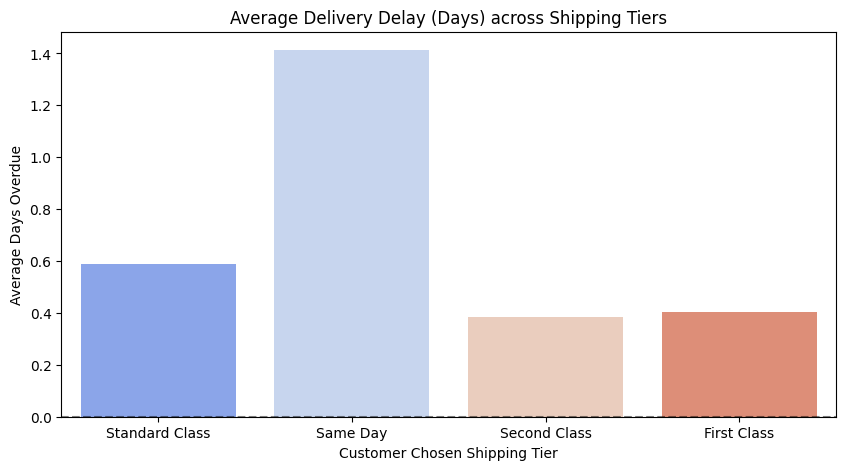

In [9]:
plt.figure(figsize=(10, 5))
# Calculating average delay per shipping tier
sns.barplot(data=df, x='Shipping_Mode', y='Delay_Days', errorbar=None, palette='coolwarm')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Average Delivery Delay (Days) across Shipping Tiers')
plt.xlabel('Customer Chosen Shipping Tier')
plt.ylabel('Average Days Overdue')
plt.show()

In [10]:
# Financial Churn Risk Assessment

In [11]:
# Assuming a industry-standard 5% revenue penalty refund/churn risk cost for late items
df['At_Risk_Capital'] = df.apply(lambda row: row['Order_Item_Total'] * 0.05 if row['Is_Late'] == 1 else 0, axis=1)

region_risk = df.groupby('Order_Region')['At_Risk_Capital'].sum().reset_index()
print("Financial risk penalty projection by global territory:")
print(region_risk)


Financial risk penalty projection by global territory:
     Order_Region  At_Risk_Capital
0            APAC      1768.355890
1           LATAM      1513.281330
2   North America      1552.489225
3  Western Europe      1487.877717
